# Generate Predictions from Trained Models

## 1. Setup and Imports

In [1]:
import os
import sys
import torch
import pandas as pd
import numpy as np
from pathlib import Path
from lightning.pytorch import Trainer
from datetime import datetime

import matplotlib.pyplot as plt

from cybench.datasets.configured import load_dfs_crop
from cybench.datasets.dataset import Dataset as CYDataset
from cybench.config import KEY_LOC, KEY_YEAR

project_root = Path.cwd().parent
sys.path.append(str(project_root / 'process'))
sys.path.append(str(project_root / 'architectures'))

from loadData import DailyCYBenchSeqDataModule, calculate_fixed_split
from modelconfig import TSTModelConfig, LinearModelConfig
from tstLayer import create_model as create_tst_model
from linearLayer import create_model as create_linear_model

/gpfs/home4/vsaxena1/miniconda3/envs/cybench/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Feature Config] SOTA Temporal vars (6): ['sin_doy', 'cos_doy', 'sin_month', 'cos_month', 'season_sin', 'season_cos']
[Feature Config] Static vars (4): ['awc', 'bulk_density', 'latitude', 'longitude']
[Feature Config] Static vars (4): ['awc', 'bulk_density', 'latitude', 'longitude']
[Feature Config] SOTA Temporal vars (6): ['sin_doy', 'cos_doy', 'sin_month', 'cos_month', 'season_sin', 'season_cos']
[Feature Config] SOTA Temporal vars (6): ['sin_doy', 'cos_doy', 'sin_month', 'cos_month', 'season_sin', 'season_cos']
[Feature Config] SOTA Temporal vars (6): ['sin_doy', 'cos_doy', 'sin_month', 'cos_month', 'season_sin', 'season_cos']


## 2. Load Baseline Configurations

In [2]:
tst_baseline = pd.read_csv("/gpfs/home4/vsaxena1/AgML-CY-Bench/cybench/train/HFcheckpoints/yield-transformers-cybench/config-and-results.csv")
linear_baseline = pd.read_csv("/gpfs/home4/vsaxena1/AgML-CY-Bench/cybench/train/HFcheckpoints/yield-linear-cybench/config-and-results.csv")

print(f"Loaded TST baseline: {len(tst_baseline)} configs")
print(f"Loaded Linear baseline: {len(linear_baseline)} configs")

Loaded TST baseline: 560 configs
Loaded Linear baseline: 310 configs


## 3. Helper Functions

In [3]:
class AttrDict(dict):
    def __getattr__(self, key):
        try:
            return self[key]
        except KeyError:
            raise AttributeError(key)
    def __setattr__(self, key, value):
        self[key] = value

def fetch_config_and_runid(df, country, model_name, crop):
    df = df[(df["model_type"] == model_name) & (df["country"] == country) & (df["crop"] == crop)]
    return AttrDict(eval(list(df.config.to_dict().values())[0])), list(df["run_id"].unique())[0]

def get_checkpoint_path(config_dict, checkpoint_name):
    if config_dict["model_type"] in ['autoformer', 'patchtst', 'tsmixer', 'informer', 'tst', 'itransformer', 'timexer', 'timesnet']:
        model_dir = "/gpfs/home4/vsaxena1/AgML-CY-Bench/cybench/train/HFcheckpoints/yield-transformers-cybench"
    else:
        model_dir = "/gpfs/home4/vsaxena1/AgML-CY-Bench/cybench/train/HFcheckpoints/yield-linear-cybench"
    checkpoint_dir = os.path.join(model_dir, config_dict["model_type"], config_dict["crop"], config_dict["country"], f"{checkpoint_name}.ckpt")
    return checkpoint_dir

# TST-specific arguments that should be filtered out for LinearModelConfig
TST_ONLY_ARGS = ['use_revin']

def create_model_config(config_dict):
    if config_dict["model_type"] in ['autoformer', 'patchtst', 'tsmixer', 'informer', 'tst', 'itransformer', 'timexer', 'timesnet']:
        return TSTModelConfig(**config_dict)
    else:
        # Filter out TST-only arguments for linear models
        filtered_config = {k: v for k, v in config_dict.items() if k not in TST_ONLY_ARGS}
        return LinearModelConfig(**filtered_config)

## 4. Main Wrapper Function

In [ ]:
def generate_predictions_wrapper(model_type, country, crop, checkpoint_name=None, 
                                   output_dir='/gpfs/home4/vsaxena1/AgML-CY-Bench/cybench/wrappers/data'):
    """
    Generate predictions from a trained model.
    
    Args:
        model_type: Model type (e.g., 'patchtst', 'nlinear', 'dlinear')
        country: Country code (e.g., 'NL', 'US', 'IN')
        crop: Crop type (e.g., 'maize', 'wheat', 'rice')
        checkpoint_name: Optional checkpoint name. If None, fetched from config.
        output_dir: Directory to save predictions CSV.
    
    Returns:
        predictions_df: DataFrame with adm_id, year, lat, lon, predicted_yield, actual_yield, error, abs_error, pct_error
    """
    # Determine which baseline to use
    if model_type in ['autoformer', 'patchtst', 'tsmixer', 'informer', 'tst', 'itransformer', 'timexer', 'timesnet']:
        baseline_df = tst_baseline
    else:
        baseline_df = linear_baseline
    
    # Fetch config and checkpoint
    config_dict, fetched_checkpoint_name = fetch_config_and_runid(baseline_df, country, model_type, crop)
    if checkpoint_name is None:
        checkpoint_name = fetched_checkpoint_name
    checkpoint_dir = get_checkpoint_path(config_dict, checkpoint_name)
    
    # Create model config
    model_config = create_model_config(config_dict)
    
    # Load data and setup datamodule
    df_y, dfs_x = load_dfs_crop(config_dict["crop"], [config_dict["country"]])
    if df_y is None or len(df_y) == 0:
        raise ValueError(f"No data found for {config_dict['crop']}-{config_dict['country']}")
    
    ds = CYDataset(config_dict["crop"], df_y, dfs_x)
    all_years = sorted(set([ds[i][KEY_YEAR] for i in range(len(ds))]))
    
    fixed_splits = calculate_fixed_split(all_years, test_years=config_dict["test_years"], val_years=2)
    
    dm = DailyCYBenchSeqDataModule(model_config)
    dm.setup(
        train_years=fixed_splits['train_years'],
        val_years=fixed_splits['val_years'],
        test_years=fixed_splits['test_years']
    )
    
    # Create model
    if model_config.model_type in ['autoformer', 'patchtst', 'tsmixer', 'informer', 'tst', 'itransformer', 'timexer', 'timesnet']:
        model = create_tst_model(model_config)
    else:
        model = create_linear_model(model_config)
    
    # Load checkpoint
    if not os.path.exists(checkpoint_dir):
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_dir}")
    
    checkpoint = torch.load(checkpoint_dir, map_location='cpu')
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()
    
    # Setup trainer and generate predictions
    device = 'gpu' if torch.cuda.is_available() else 'cpu'
    trainer = Trainer(accelerator=device, devices=1, enable_progress_bar=True, logger=False)
    
    trainer.datamodule = dm
    model.trainer = trainer
    model.eval()
    
    predictions_list = []
    for batch in dm.test_dataloader():
        with torch.no_grad():
            result = model.predict(batch)
            predictions_list.append({
                'predictions': result['predictions'].cpu().numpy(),
                'targets': result['targets'].cpu().numpy(),
                'years': result['years'].cpu().numpy(),
                'adm_ids': result['adm_ids'],
                'lats': result['lats'].cpu().numpy(),
                'lons': result['lons'].cpu().numpy(),
            })
    
    # Combine results into DataFrame
    all_preds = []
    for batch_preds in predictions_list:
        for i in range(len(batch_preds['predictions'])):
            all_preds.append({
                'adm_id': batch_preds['adm_ids'][i],
                'year': int(batch_preds['years'][i]),
                'lat': batch_preds['lats'][i],
                'lon': batch_preds['lons'][i],
                'predicted_yield': batch_preds['predictions'][i].item(),
                'actual_yield': batch_preds['targets'][i].item(),
            })
    
    predictions_df = pd.DataFrame(all_preds)
    
    # Calculate error metrics
    predictions_df['error'] = predictions_df['predicted_yield'] - predictions_df['actual_yield']
    predictions_df['abs_error'] = predictions_df['error'].abs()
    predictions_df['pct_error'] = (predictions_df['error'] / predictions_df['actual_yield'] * 100)
    
    # Save to CSV
    os.makedirs(output_dir, exist_ok=True)
    output_csv = f'{model_type}-{crop}-{country}-predictions.csv'
    output_path = os.path.join(output_dir, output_csv)
    predictions_df.to_csv(output_path, index=False)
    
    print(f"Predictions saved to: {output_path}")
    
    return predictions_df

## 5. Usage

In [40]:
patchtst_predictions_df = generate_predictions_wrapper(
    model_type='patchtst',
    country='DE',
    crop='maize'
)


[DataModule] maize-DE | DAILY | Spatial=False | Lag=0
  Static features validated: 9/9
  Split: Train [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014], Val [2015, 2016], Test [2017, 2018, 2019, 2020, 2021]
  Years Summary:
    Train years (11): [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]
    Val years (2):   [2015, 2016]
    Test years (5):  [2017, 2018, 2019, 2020, 2021]
  Y norm: mean=9.3014, std=1.3157
  Feature norm params: 19 features
  Samples: train=2236, val=344, test=579
[Model] TS features=10, Static features=9


/scratch-local/75414/ipykernel_3555297/407885038.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_dir, map_location='cpu')
/gpfs/home4

Predictions saved to: /gpfs/home4/vsaxena1/AgML-CY-Bench/cybench/wrappers/data/patchtst-maize-DE-predictions.csv


In [41]:
xlinear_predictions_df = generate_predictions_wrapper(
    model_type='xlinear',
    country='DE',
    crop='maize'
)


[DataModule] maize-DE | DAILY | Spatial=False | Lag=0
  Static features validated: 9/9
  Split: Train [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014], Val [2015, 2016], Test [2017, 2018, 2019, 2020, 2021]
  Years Summary:
    Train years (11): [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]
    Val years (2):   [2015, 2016]
    Test years (5):  [2017, 2018, 2019, 2020, 2021]
  Y norm: mean=9.3014, std=1.3157
  Feature norm params: 19 features
  Samples: train=2236, val=344, test=579
[Model] TS features=10, Static features=9


/scratch-local/75414/ipykernel_3555297/407885038.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_dir, map_location='cpu')
/gpfs/home4

Predictions saved to: /gpfs/home4/vsaxena1/AgML-CY-Bench/cybench/wrappers/data/xlinear-maize-DE-predictions.csv


In [47]:
crop = "maize"
country = "DE"
if crop == "wheat":
    irrigated_filename = os.path.join(f"irrigated_temperate_cereals_yield", f"irrigated_temperate_cereals_yield_{crop}_{country}.csv")
    rainfed_filename = os.path.join(f"rainfed_temperate_cereals_yield", f"rainfed_temperate_cereals_yield_{crop}_{country}.csv")
else:
    irrigated_filename = os.path.join("irrigated_maize_yield", f"irrigated_{crop}_yield_{crop}_{country}.csv")
    rainfed_filename = os.path.join("rainfed_maize_yield", f"rainfed_{crop}_yield_{crop}_{country}.csv")
irrigated_lpjml_model = pd.read_csv(os.path.join("/gpfs/home4/vsaxena1/AgML-CY-Bench/cybench/visualize/data/LPJmL/region_aggregated/region_aggregated/", crop, country, irrigated_filename))
rainfed_lpjml_model = pd.read_csv(os.path.join("/gpfs/home4/vsaxena1/AgML-CY-Bench/cybench/visualize/data/LPJmL/region_aggregated/region_aggregated/", crop, country, rainfed_filename))

In [48]:
irrigated_lpjml_model["date"] = irrigated_lpjml_model["date"].apply(lambda x: datetime.strptime(str(x), "%Y%m%d").strftime("%d-%m-%Y"))
rainfed_lpjml_model["date"] = rainfed_lpjml_model["date"].apply(lambda x: datetime.strptime(str(x), "%Y%m%d").strftime("%d-%m-%Y"))

In [49]:
irrigated_lpjml_model["year"] = irrigated_lpjml_model["date"].apply(lambda x: str(x).split("-")[-1])
rainfed_lpjml_model["year"] = rainfed_lpjml_model["date"].apply(lambda x: str(x).split("-")[-1])

## 6. Analysis

In [24]:
def generate_stats(predictions_df):
    print("=" * 50)
    print("Predictions Statistics")
    print("=" * 50)
    print(f"\nMean Actual Yield:    {predictions_df['actual_yield'].mean():.4f} t/ha")
    print(f"Mean Predicted Yield: {predictions_df['predicted_yield'].mean():.4f} t/ha")
    print(f"\nMean Absolute Error:  {predictions_df['abs_error'].mean():.4f} t/ha")
    print(f"RMSE:                  {np.sqrt((predictions_df['error']**2).mean()):.4f} t/ha")

    y_true = predictions_df['actual_yield'].values
    y_pred = predictions_df['predicted_yield'].values
    rmse = np.sqrt((predictions_df['error']**2).mean())
    nrmse = rmse / (y_true.max() - y_true.min())
    print(f"NRMSE:                 {nrmse:.4f} (range-normalized)")
    print(f"Mean % Error:          {predictions_df['pct_error'].mean():.2f}%")

    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    r2 = 1 - (ss_res / ss_tot)
    print(f"R²:                    {r2:.4f}")

In [25]:
def calculate_nrmse_group(group):
    y_true = group['actual_yield'].values
    y_pred = group['predicted_yield'].values
    rmse = np.sqrt(((y_true - y_pred) ** 2).mean())
    return rmse / (y_true.max() - y_true.min()) if (y_true.max() - y_true.min()) > 0 else np.nan

def generate_per_year_stats(predictions_df):

    print("\n" + "=" * 50)
    print("Per-year Stats")
    print("=" * 50)


    per_year_stats = predictions_df.groupby('year').agg({
        'predicted_yield': 'mean',
        'actual_yield': 'mean',
        'error': 'mean',
        'abs_error': 'mean',
    }).round(4)

    nrmse_per_year = predictions_df.groupby('year').apply(calculate_nrmse_group)
    per_year_stats['NRMSE'] = nrmse_per_year
    per_year_stats.columns = ['Mean Pred', 'Mean Actual', 'Mean Error', 'MAE', 'NRMSE']
    print(per_year_stats)

In [26]:
# Plot predictions vs actuals
def plot_predictions(predictions_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(predictions_df['actual_yield'], predictions_df['predicted_yield'], alpha=0.6)
    axes[0].plot([predictions_df['actual_yield'].min(), predictions_df['actual_yield'].max()],
            [predictions_df['actual_yield'].min(), predictions_df['actual_yield'].max()],
            'r--', label='Perfect prediction')
    axes[0].set_xlabel('Actual Yield (t/ha)')
    axes[0].set_ylabel('Predicted Yield (t/ha)')
    axes[0].set_title('Predicted vs Actual Yield')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    yearly = predictions_df.groupby('year')[['predicted_yield', 'actual_yield']].mean()
    x = np.arange(len(yearly))
    width = 0.35

    axes[1].bar(x - width/2, yearly['actual_yield'], width, label='Actual', alpha=0.8)
    axes[1].bar(x + width/2, yearly['predicted_yield'], width, label='Predicted', alpha=0.8)
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Mean Yield (t/ha)')
    axes[1].set_title('Mean Yield by Year')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(yearly.index)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

In [27]:
def compare_predictions(patchtst_predictions, xlinear_predictions, rainfed_lpjml_predictions, irrigated_lpjml_predictions, crop='maize', country="NL", apply_bias_correction=True):
    """
    Compare predictions from 4 models in a 4x2 subplot grid.
    
    IMPORTANT: All models are filtered to use the SAME set of (adm_id, year) pairs
    before comparison, ensuring fair comparisons.
    
    Args:
        patchtst_predictions: DataFrame with adm_id, year, actual_yield (ground truth)
        xlinear_predictions: DataFrame with adm_id, year, actual_yield (ground truth)
        rainfed_lpjml_predictions: LPJML rainfed predictions
        irrigated_lpjml_predictions: LPJML irrigated predictions
        crop: Crop type ('maize', 'wheat', etc.) - determines yield column names
        apply_bias_correction: If True, apply mean bias correction to LPJML predictions
    """
    # Determine yield column names based on crop
    if crop == 'wheat':
        rainfed_yield_col = 'rainfed_temperate_cereals_yield'
        irrigated_yield_col = 'irrigated_temperate_cereals_yield'
    else:
        rainfed_yield_col = f'rainfed_{crop}_yield'
        irrigated_yield_col = f'irrigated_{crop}_yield'
    
    print(f"Using yield columns: rainfed='{rainfed_yield_col}', irrigated='{irrigated_yield_col}'")
    
    # Cross-check (adm_id, year) pairs across all data sources
    def cross_check_pairs(patchtst_df, xlinear_df, rainfed_df, irrigated_df):
        print("\n" + "=" * 80)
        print("CROSS-CHECK: (adm_id, year) pairs across all data sources")
        print("=" * 80)
        
        # Extract pairs from each source
        def get_pairs(df, adm_col='adm_id', year_col='year'):
            df_copy = df.copy()
            df_copy[adm_col] = df_copy[adm_col].astype(str)
            if year_col == 'year':
                # Handle year as string or int
                df_copy['_year_int'] = pd.to_numeric(df_copy[year_col], errors='coerce')
                # Drop rows with NaN years to avoid issues in pair comparisons
                df_copy = df_copy.dropna(subset=['_year_int'])
                return set(zip(df_copy[adm_col], df_copy['_year_int']))
            else:
                return set(zip(df_copy[adm_col], df_copy[year_col]))
        
        patchtst_pairs = get_pairs(patchtst_df)
        xlinear_pairs = get_pairs(xlinear_df)
        rainfed_pairs = get_pairs(rainfed_df)
        irrigated_pairs = get_pairs(irrigated_df)
        
        # Print summary
        print(f"\nPatchTST:        {len(patchtst_pairs)} unique (adm_id, year) pairs")
        print(f"XLinear:         {len(xlinear_pairs)} unique (adm_id, year) pairs")
        print(f"Rainfed LPJML:   {len(rainfed_pairs)} unique (adm_id, year) pairs")
        print(f"Irrigated LPJML: {len(irrigated_pairs)} unique (adm_id, year) pairs")
        
        # Find the COMMON intersection across all datasets
        common_pairs = patchtst_pairs & xlinear_pairs & rainfed_pairs & irrigated_pairs
        print(f"\n--- Common pairs (intersection of ALL 4 datasets) ---")
        print(f"Common pairs:    {len(common_pairs)} unique (adm_id, year) pairs")
        
        # Check for missing pairs relative to the common set
        print(f"\n--- Missing pairs relative to common set ---")
        print(f"PatchTST missing from common:  {len(patchtst_pairs - common_pairs)} pairs")
        print(f"XLinear missing from common:   {len(xlinear_pairs - common_pairs)} pairs")
        print(f"Rainfed missing from common:   {len(rainfed_pairs - common_pairs)} pairs")
        print(f"Irrigated missing from common: {len(irrigated_pairs - common_pairs)} pairs")
        
        return {
            'patchtst': patchtst_pairs,
            'xlinear': xlinear_pairs,
            'rainfed_lpjml': rainfed_pairs,
            'irrigated_lpjml': irrigated_pairs,
            'common': common_pairs,
        }
    
    # Run cross-check
    pair_stats = cross_check_pairs(patchtst_predictions, xlinear_predictions, 
                                   rainfed_lpjml_predictions, irrigated_lpjml_predictions)
    
    # Get the common set of (adm_id, year) pairs
    common_pairs = pair_stats['common']
    
    if len(common_pairs) == 0:
        print("WARNING: No common (adm_id, year) pairs across all datasets!")
        print("Cannot make fair comparison. Using individual datasets as-is.")
        use_common_filter = False
    else:
        print(f"\nUsing {len(common_pairs)} common (adm_id, year) pairs for fair comparison.")
        use_common_filter = True
    
    # Prepare LPJML data - merge with ground truth from patchtst
    def prepare_lpjml_data(lpjml_df, yield_col, actual_df, apply_bias_correction=True, common_pairs=None):
        lpjml = lpjml_df.copy()
        
        # Handle year extraction
        if 'year' in lpjml.columns:
            lpjml['year_int'] = pd.to_numeric(lpjml['year'], errors='coerce').astype(int)
        elif 'date' in lpjml.columns:
            date_str = lpjml['date'].astype(str).iloc[0] if len(lpjml) > 0 else ""
            if '-' in date_str and date_str.split('-')[-1].isdigit():
                lpjml['year_int'] = lpjml['date'].astype(str).str.split('-').str[-1].astype(int)
            else:
                lpjml['year_int'] = lpjml['date'].astype(str).str[:4].astype(int)
        else:
            raise ValueError("Cannot find 'date' or 'year' column in LPJML data")
        
        # Ensure adm_id is string for consistent merging
        lpjml['adm_id'] = lpjml['adm_id'].astype(str)
        
        # Merge with ground truth from actual_df
        actual_df_copy = actual_df.copy()
        actual_df_copy['adm_id'] = actual_df_copy['adm_id'].astype(str)
        actual_df_copy['year_int'] = actual_df_copy['year'].astype(int)
        
        merged = lpjml.merge(actual_df_copy[['adm_id', 'year_int', 'actual_yield']], 
                            on=['adm_id', 'year_int'], how='inner')
        
        if len(merged) == 0:
            print(f"Warning: No matches found for {yield_col}.")
            result = lpjml.rename(columns={yield_col: 'predicted_yield'})
            result['actual_yield'] = np.nan
            result['error'] = np.nan
            result['abs_error'] = np.nan
            result['year'] = result['year_int']
            return result
        
        merged = merged.rename(columns={yield_col: 'predicted_yield'})
        
        # Apply bias correction if requested
        if apply_bias_correction and len(merged) > 0:
            bias = (merged['predicted_yield'] - merged['actual_yield']).mean()
            merged['predicted_yield_raw'] = merged['predicted_yield'].copy()
            merged['predicted_yield'] = merged['predicted_yield'] - bias
            print(f"{yield_col}: Applied bias correction of {bias:.4f} t/ha")
        
        merged['error'] = merged['predicted_yield'] - merged['actual_yield']
        merged['abs_error'] = merged['error'].abs()
        merged['pct_error'] = (merged['error'] / merged['actual_yield'] * 100)
        merged['year'] = merged['year_int']
        
        # Filter to common pairs if specified
        if common_pairs is not None and len(common_pairs) > 0:
            merged['_pair_key'] = list(zip(merged['adm_id'].astype(str), merged['year_int']))
            merged = merged[merged['_pair_key'].isin(common_pairs)].copy()
            merged = merged.drop(columns=['_pair_key'])
            print(f"{yield_col}: Filtered to {len(merged)} rows (common pairs)")
        
        return merged
    
    rainfed_df = prepare_lpjml_data(rainfed_lpjml_predictions, rainfed_yield_col, patchtst_predictions, apply_bias_correction, common_pairs if use_common_filter else None)
    irrigated_df = prepare_lpjml_data(irrigated_lpjml_predictions, irrigated_yield_col, patchtst_predictions, apply_bias_correction, common_pairs if use_common_filter else None)
    
    # Also filter PatchTST and XLinear to common pairs
    def filter_to_common(df, common_pairs=None):
        if common_pairs is None or len(common_pairs) == 0:
            return df
        df_copy = df.copy()
        df_copy['_pair_key'] = list(zip(df_copy['adm_id'].astype(str), df_copy['year'].astype(int)))
        df_filtered = df_copy[df_copy['_pair_key'].isin(common_pairs)].copy()
        df_filtered = df_filtered.drop(columns=['_pair_key'])
        return df_filtered
    
    if use_common_filter:
        patchtst_filtered = filter_to_common(patchtst_predictions, common_pairs)
        xlinear_filtered = filter_to_common(xlinear_predictions, common_pairs)
        print(f"PatchTST: Filtered to {len(patchtst_filtered)} rows (common pairs)")
        print(f"XLinear: Filtered to {len(xlinear_filtered)} rows (common pairs)")
    else:
        patchtst_filtered = patchtst_predictions
        xlinear_filtered = xlinear_predictions
    
    # Create 4x2 subplot
    fig, axes = plt.subplots(4, 2, figsize=(14, 16))
    
    models = [
        ('PatchTST', patchtst_filtered, axes[0, 0], axes[0, 1]),
        ('XLinear', xlinear_filtered, axes[1, 0], axes[1, 1]),
        ('Rainfed LPJML', rainfed_df, axes[2, 0], axes[2, 1]),
        ('Irrigated LPJML', irrigated_df, axes[3, 0], axes[3, 1]),
    ]
    
    for model_name, df, ax1, ax2 in models:
        # Check if we have actual yields (ground truth)
        has_ground_truth = df['actual_yield'].notna().any()
        
        if has_ground_truth:
            # Scatter plot with ground truth comparison
            ax1.scatter(df['actual_yield'], df['predicted_yield'], alpha=0.6, s=30)
            min_val = min(df['actual_yield'].min(), df['predicted_yield'].min())
            max_val = max(df['actual_yield'].max(), df['predicted_yield'].max())
            ax1.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect', linewidth=2)
            ax1.set_xlabel('Actual Yield (t/ha)')
            ax1.set_ylabel('Predicted Yield (t/ha)')
            ax1.set_title(f'{model_name.upper()}-{crop.upper()}-{country}: Predicted vs Actual')
            
            # Add stats box
            rmse = np.sqrt((df['error']**2).mean())
            mae = df['abs_error'].mean()
            y_true = df['actual_yield'].values
            y_pred = df['predicted_yield'].values
            ss_res = ((y_true - y_pred) ** 2).sum()
            ss_tot = ((y_true - y_true.mean()) ** 2).sum()
            r2 = 1 - (ss_res / ss_tot)
            nrmse = rmse / (y_true.max() - y_true.min())
            bias_correction_note = " (bias-corrected)" if apply_bias_correction and 'LPJML' in model_name else ""
            filter_note = f" | n={len(df)}" if use_common_filter else ""
            stats_text = f'RMSE: {rmse:.3f} | MAE: {mae:.3f} | R2: {r2:.3f} | NRMSE: {nrmse:.3f}{bias_correction_note}{filter_note}'
            ax1.text(0.05, 0.95, stats_text, transform=ax1.transAxes, 
                    fontsize=9, verticalalignment='top', 
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        else:
            # No ground truth - show distribution of predictions
            ax1.hist(df['predicted_yield'], bins=20, alpha=0.7, color='coral', edgecolor='black')
            ax1.set_xlabel('Predicted Yield (t/ha)')
            ax1.set_ylabel('Frequency')
            ax1.set_title(f'{model_name}: Yield Distribution (No Ground Truth)')
            ax1.text(0.05, 0.95, 'No ground truth data available', transform=ax1.transAxes,
                    fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
        
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Bar chart - always show by year
        yearly = df.groupby('year')['predicted_yield'].mean()
        x = np.arange(len(yearly))
        
        if has_ground_truth:
            yearly_actual = df.groupby('year')['actual_yield'].mean()
            width = 0.35
            ax2.bar(x - width/2, yearly_actual, width, label='Actual', alpha=0.8, color='steelblue')
            ax2.bar(x + width/2, yearly, width, label='Predicted', alpha=0.8, color='coral')
        else:
            width = 0.5
            ax2.bar(x, yearly, width, label='LPJML Predicted', alpha=0.8, color='coral')
        
        ax2.set_xlabel('Year')
        ax2.set_ylabel('Mean Yield (t/ha)')
        ax2.set_title(f'{model_name.upper()}-{crop.upper()}-{country}: Mean Yield by Year')
        ax2.set_xticks(x)
        ax2.set_xticklabels(yearly.index)
        ax2.legend()
        ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "=" * 80)
    print("MODEL COMPARISON SUMMARY")
    if use_common_filter:
        print(f"(All models filtered to {len(common_pairs)} common (adm_id, year) pairs)")
    print("=" * 80)
    for model_name, df, _, _ in models:
        if df['actual_yield'].notna().any():
            rmse = np.sqrt((df['error']**2).mean())
            mae = df['abs_error'].mean()
            y_true = df['actual_yield'].values
            y_pred = df['predicted_yield'].values
            ss_res = ((y_true - y_pred) ** 2).sum()
            ss_tot = ((y_true - y_true.mean()) ** 2).sum()
            r2 = 1 - (ss_res / ss_tot)
            nrmse = rmse / (y_true.max() - y_true.min())
            bias_note = " (bias-corrected)" if apply_bias_correction and 'LPJML' in model_name else ""
            print(f"{model_name:20s}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}, NRMSE={nrmse:.4f}{bias_note}, n={len(df)}")
        else:
            print(f"{model_name:20s}: No ground truth available - {len(df)} predictions")

Using yield columns: rainfed='rainfed_maize_yield', irrigated='irrigated_maize_yield'

CROSS-CHECK: (adm_id, year) pairs across all data sources

PatchTST:        579 unique (adm_id, year) pairs
XLinear:         579 unique (adm_id, year) pairs
Rainfed LPJML:   9200 unique (adm_id, year) pairs
Irrigated LPJML: 9200 unique (adm_id, year) pairs

--- Common pairs (intersection of ALL 4 datasets) ---
Common pairs:    579 unique (adm_id, year) pairs

--- Missing pairs relative to common set ---
PatchTST missing from common:  0 pairs
XLinear missing from common:   0 pairs
Rainfed missing from common:   8621 pairs
Irrigated missing from common: 8621 pairs

Using 579 common (adm_id, year) pairs for fair comparison.
rainfed_maize_yield: Applied bias correction of -4.0296 t/ha
rainfed_maize_yield: Filtered to 579 rows (common pairs)
irrigated_maize_yield: Applied bias correction of -3.0633 t/ha
irrigated_maize_yield: Filtered to 579 rows (common pairs)
PatchTST: Filtered to 579 rows (common pairs

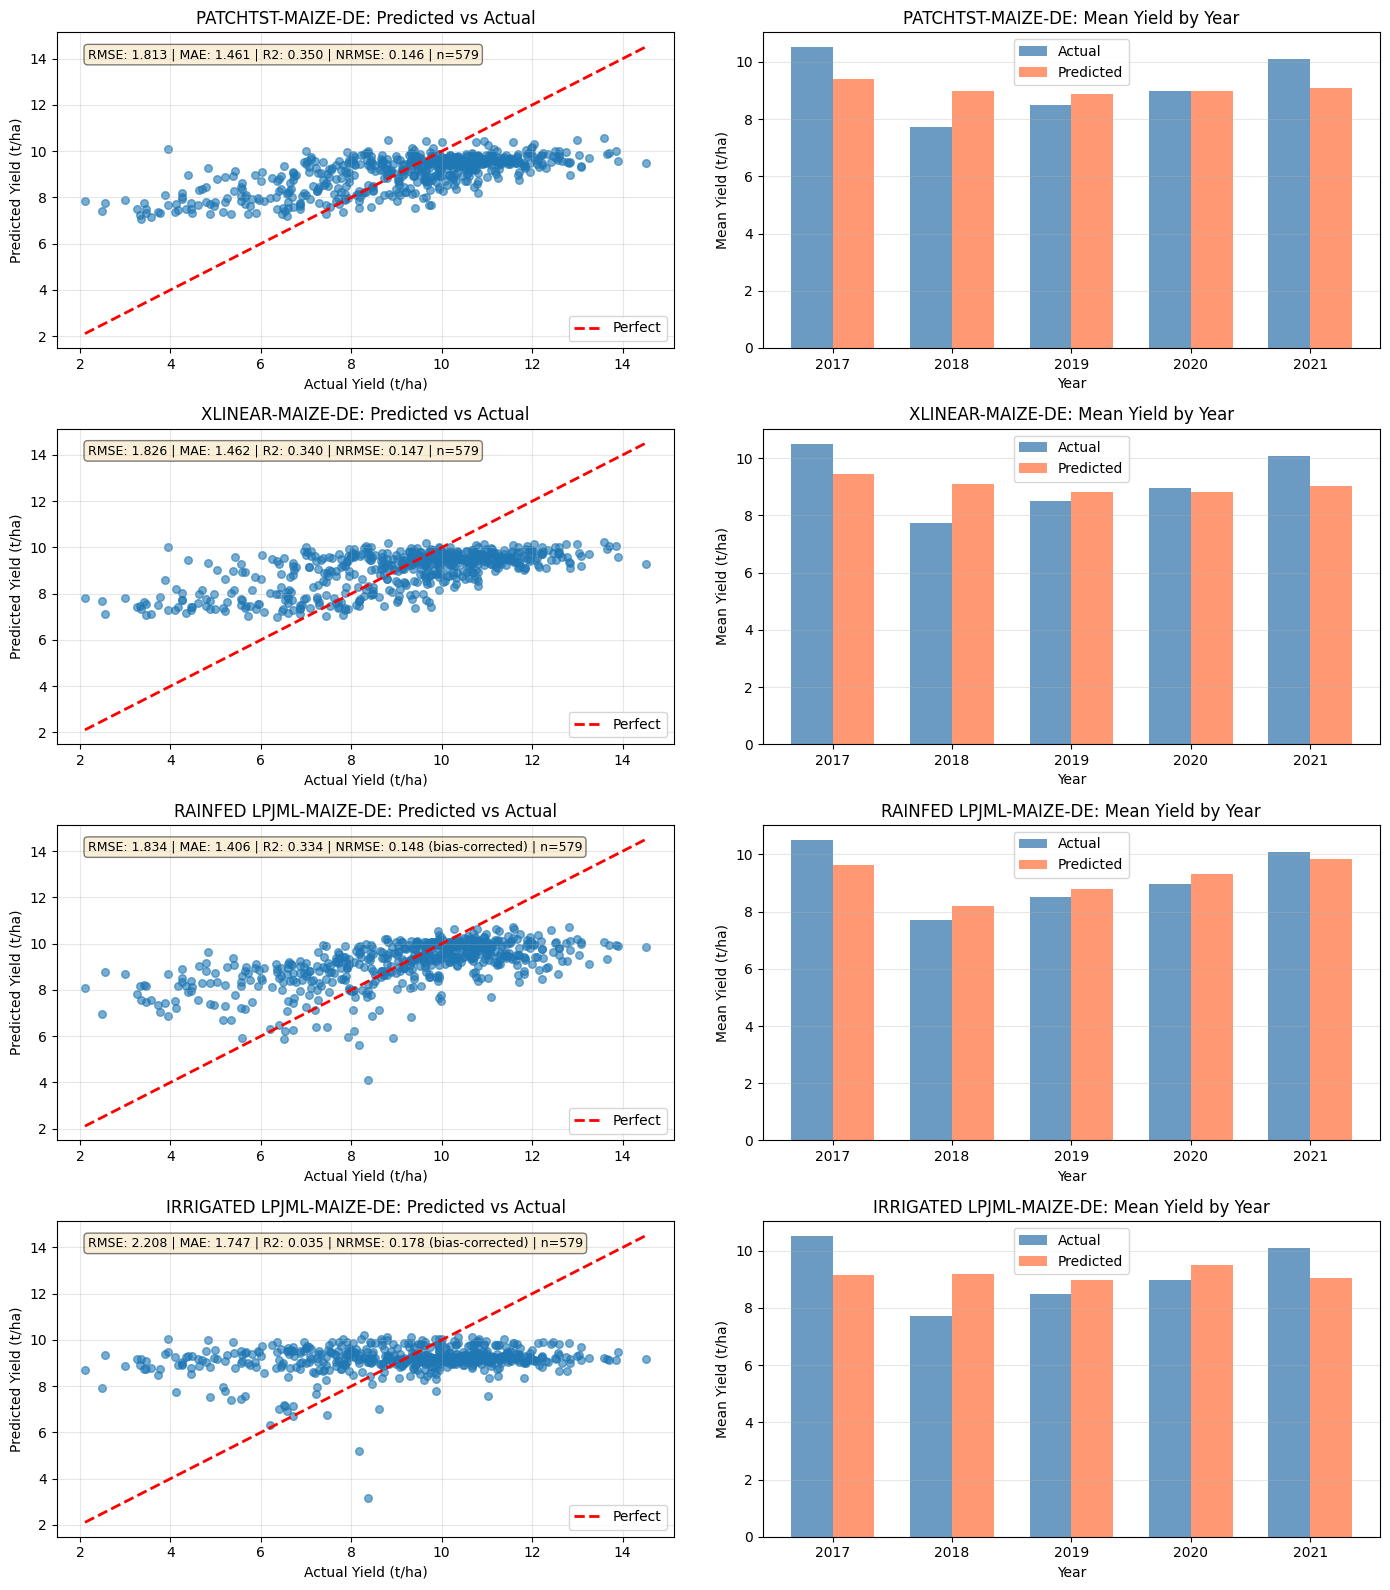


MODEL COMPARISON SUMMARY
(All models filtered to 579 common (adm_id, year) pairs)
PatchTST            : RMSE=1.8129, MAE=1.4608, R2=0.3495, NRMSE=0.1461, n=579
XLinear             : RMSE=1.8258, MAE=1.4622, R2=0.3403, NRMSE=0.1471, n=579
Rainfed LPJML       : RMSE=1.8340, MAE=1.4063, R2=0.3343, NRMSE=0.1478 (bias-corrected), n=579
Irrigated LPJML     : RMSE=2.2083, MAE=1.7468, R2=0.0349, NRMSE=0.1779 (bias-corrected), n=579


In [50]:
compare_predictions(patchtst_predictions_df, xlinear_predictions_df, rainfed_lpjml_model, irrigated_lpjml_model, crop='maize', country="DE")

In [30]:
patchtst_predictions_df


,adm_id,year,lat,lon,predicted_yield,actual_yield,error,abs_error,pct_error
0,NL11,2017,53.304138,6.79913,8.015823,9.027000,-1.011177,1.011177,-11.201695
1,NL11,2018,53.304138,6.79913,8.170605,8.688000,-0.517395,0.517395,-5.955284
2,NL11,2019,53.304138,6.79913,7.947587,9.057000,-1.109413,1.109413,-12.249234
3,NL11,2020,53.304138,6.79913,7.771448,8.669000,-0.897552,0.897552,-10.353577
4,NL12,2017,53.300850,5.68783,8.231896,9.346000,-1.114103,1.114103,-11.920644
5,NL12,2018,53.300850,5.68783,8.362887,8.939000,-0.576113,0.576113,-6.444935
6,NL12,2019,53.300850,5.68783,8.095776,9.569000,-1.473225,1.473225,-15.395805
7,NL12,2020,53.300850,5.68783,7.889989,8.439000,-0.549011,0.549011,-6.505637
8,NL13,2017,52.921791,6.71117,7.419000,7.772000,-0.353000,0.353000,-4.541948
9,NL13,2018,52.921791,6.71117,7.497653,7.176000,0.321653,0.321653,4.482342
